## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [313]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [314]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [315]:
rng = np.random.default_rng(seed=42)

In [316]:
from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [317]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (20682, 1321)
counts (after):  (20682, 1321)


### For filtering specific variants

In [318]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.06,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


In [319]:
counts[['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculate Aggregate level values

1. Get the columns that are area, roundness and ratio and non-SER features
2. Drop those columns
3. Sort the remaining columns to get their labels

In [320]:
cell_line_agg_df = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna()
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [321]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2415.820238,1068.276350,2115.358462,9310.675777,1123.228563,2.418000e+06,47.227396,3635.190569,0.133404,97.131325,...,0.066482,0.051583,0.044348,0.074617,0.730109,0.257773,0.476910,0.270425,0.000529,0.004023
LRRK2,2021.875701,1112.009004,1704.602551,9416.777551,785.303571,1.903551e+06,52.428042,3175.903571,0.221412,82.328004,...,0.060666,0.043065,0.040697,0.065448,0.723399,0.241826,0.531648,0.285185,0.000421,0.003122
PRKN,2076.053908,1952.357934,1410.677438,17065.391393,625.548616,2.735305e+06,94.056915,4003.532532,-0.133413,120.537051,...,0.083197,0.051577,0.039248,0.092716,0.748071,0.339158,0.710430,0.309782,0.000661,0.004936
SNCA,1951.625292,1429.647893,1496.251453,12805.726463,768.235761,2.151740e+06,73.047671,3316.071678,0.014999,102.527258,...,0.068528,0.047660,0.036714,0.074893,0.738253,0.372691,0.711612,0.341564,0.000580,0.004187


#### Create additional labels for region, star types and feature types 

In [322]:
all_columns = sorted_columns
regions = []
feature_types = []
star_types = []
organelles = []
ser_types = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if ('Symmetry' in col_sections) or ('Threshold' in col_sections) or ('Axial' in col_sections) or ('Radial' in col_sections):
        star_types.append(star_type)
        ser_types.append('None')
    elif  ('SER' in col_sections):
        star_types.append('SER')
        if 'Dark' in col_sections:
            ser_types.append('Dark')
        elif 'Ridge' in col_sections:
            ser_types.append('Ridge')
        elif 'Spot' in col_sections:
            ser_types.append('Spot')
        elif 'Edge' in col_sections:
            ser_types.append('Edge')
        elif 'Bright' in col_sections:
            ser_types.append('Bright')
        elif 'Saddle' in col_sections:
            ser_types.append('Saddle')
        elif 'Valley' in col_sections:
            ser_types.append('Valley')
        elif 'Hole' in col_sections:
            ser_types.append('Hole')
        else:
            ser_types.append('None')
        print(col_sections)
    else:
        star_types.append('None')
        ser_types.append('None')
        # print(star_type)
   
    feature_types.append(feature)
    organelles.append(organelle)


['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '

### Generate Heatmap without clustering

In [323]:
heatmap_data = heatmap_data[sorted_columns]

In [324]:
heatmap_data

,General Dimension - Cell region Area µm²,General Dimension - Cell region Length µm,General Dimension - Cell region Perimeter µm,General Dimension - Cell region Ratio Width to Length,General Dimension - Cell region Roundness,General Dimension - Cell region Width µm,General Dimension - Inner region Area µm²,General Dimension - Inner region Length µm,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Ratio Width to Length,...,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Edge
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,726.568423,60.116848,248.655207,0.322360,0.467413,15.234849,69.908371,23.123662,81.646936,0.149160,...,0.372880,0.482062,0.440218,0.536161,0.666780,0.853476,0.182623,0.215760,0.271215,0.363345
LRRK2,551.602722,59.710121,207.900039,0.328606,0.505215,13.650582,55.854834,21.086466,75.302601,0.144719,...,0.473246,0.585673,0.547600,0.665468,0.813446,1.014845,0.208063,0.235347,0.280761,0.353870
PRKN,497.592223,44.346248,160.693610,0.395902,0.579722,14.199009,60.991108,24.662721,93.538966,0.126755,...,0.486229,0.615666,0.571232,0.694023,0.860937,1.087418,0.234399,0.273833,0.337551,0.438455
SNCA,574.458821,50.105260,196.204708,0.364344,0.517447,14.488753,62.952411,23.197042,86.567868,0.141231,...,0.493932,0.620715,0.573611,0.691312,0.842428,1.048112,0.238760,0.280370,0.343157,0.440367


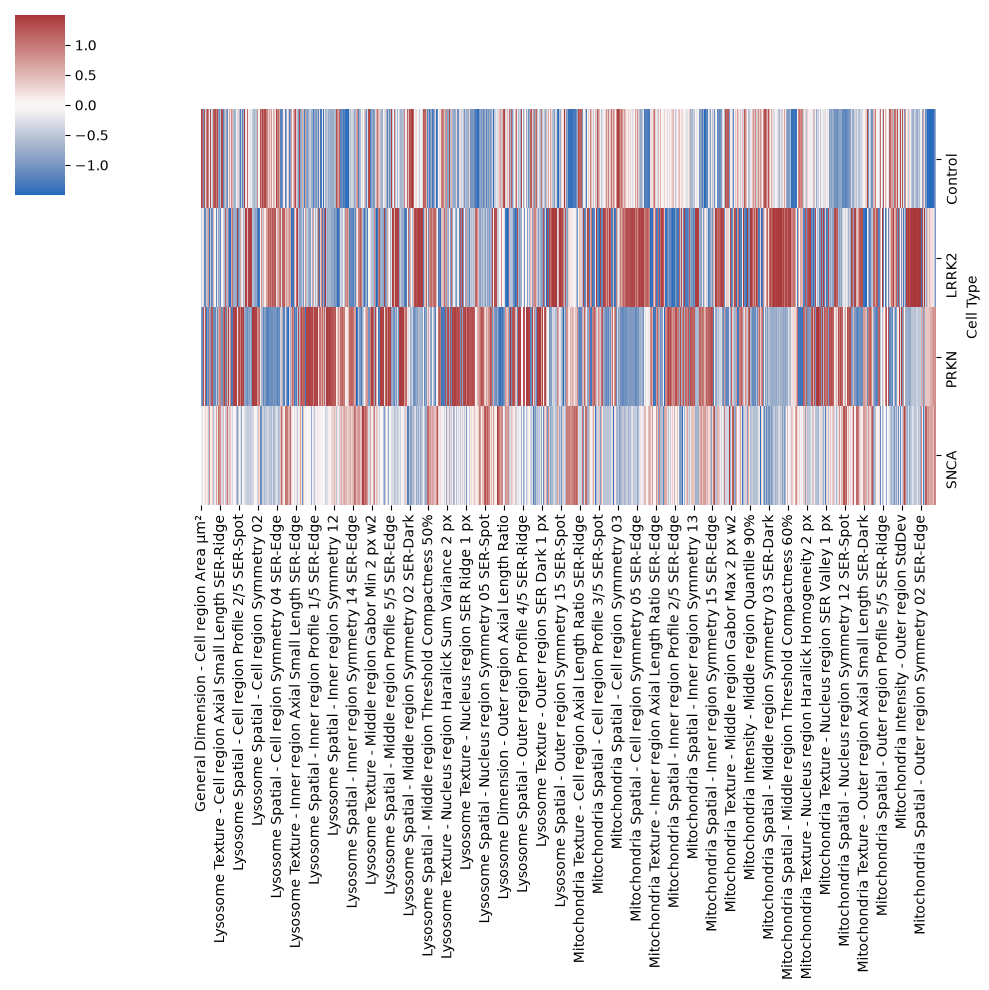

In [325]:
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
)

## Begin adding additional labels

In [326]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [327]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [328]:
set(star_types)

{'Axial', 'None', 'Radial', 'SER', 'Symmetry', 'Threshold'}

In [329]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

In [330]:
set(ser_types)

{'Bright', 'Dark', 'Edge', 'Hole', 'None', 'Ridge', 'Saddle', 'Spot', 'Valley'}

In [331]:
len(ser_types)

1320

In [332]:
len(feature_types)

1320

In [333]:
len(star_types)

1320

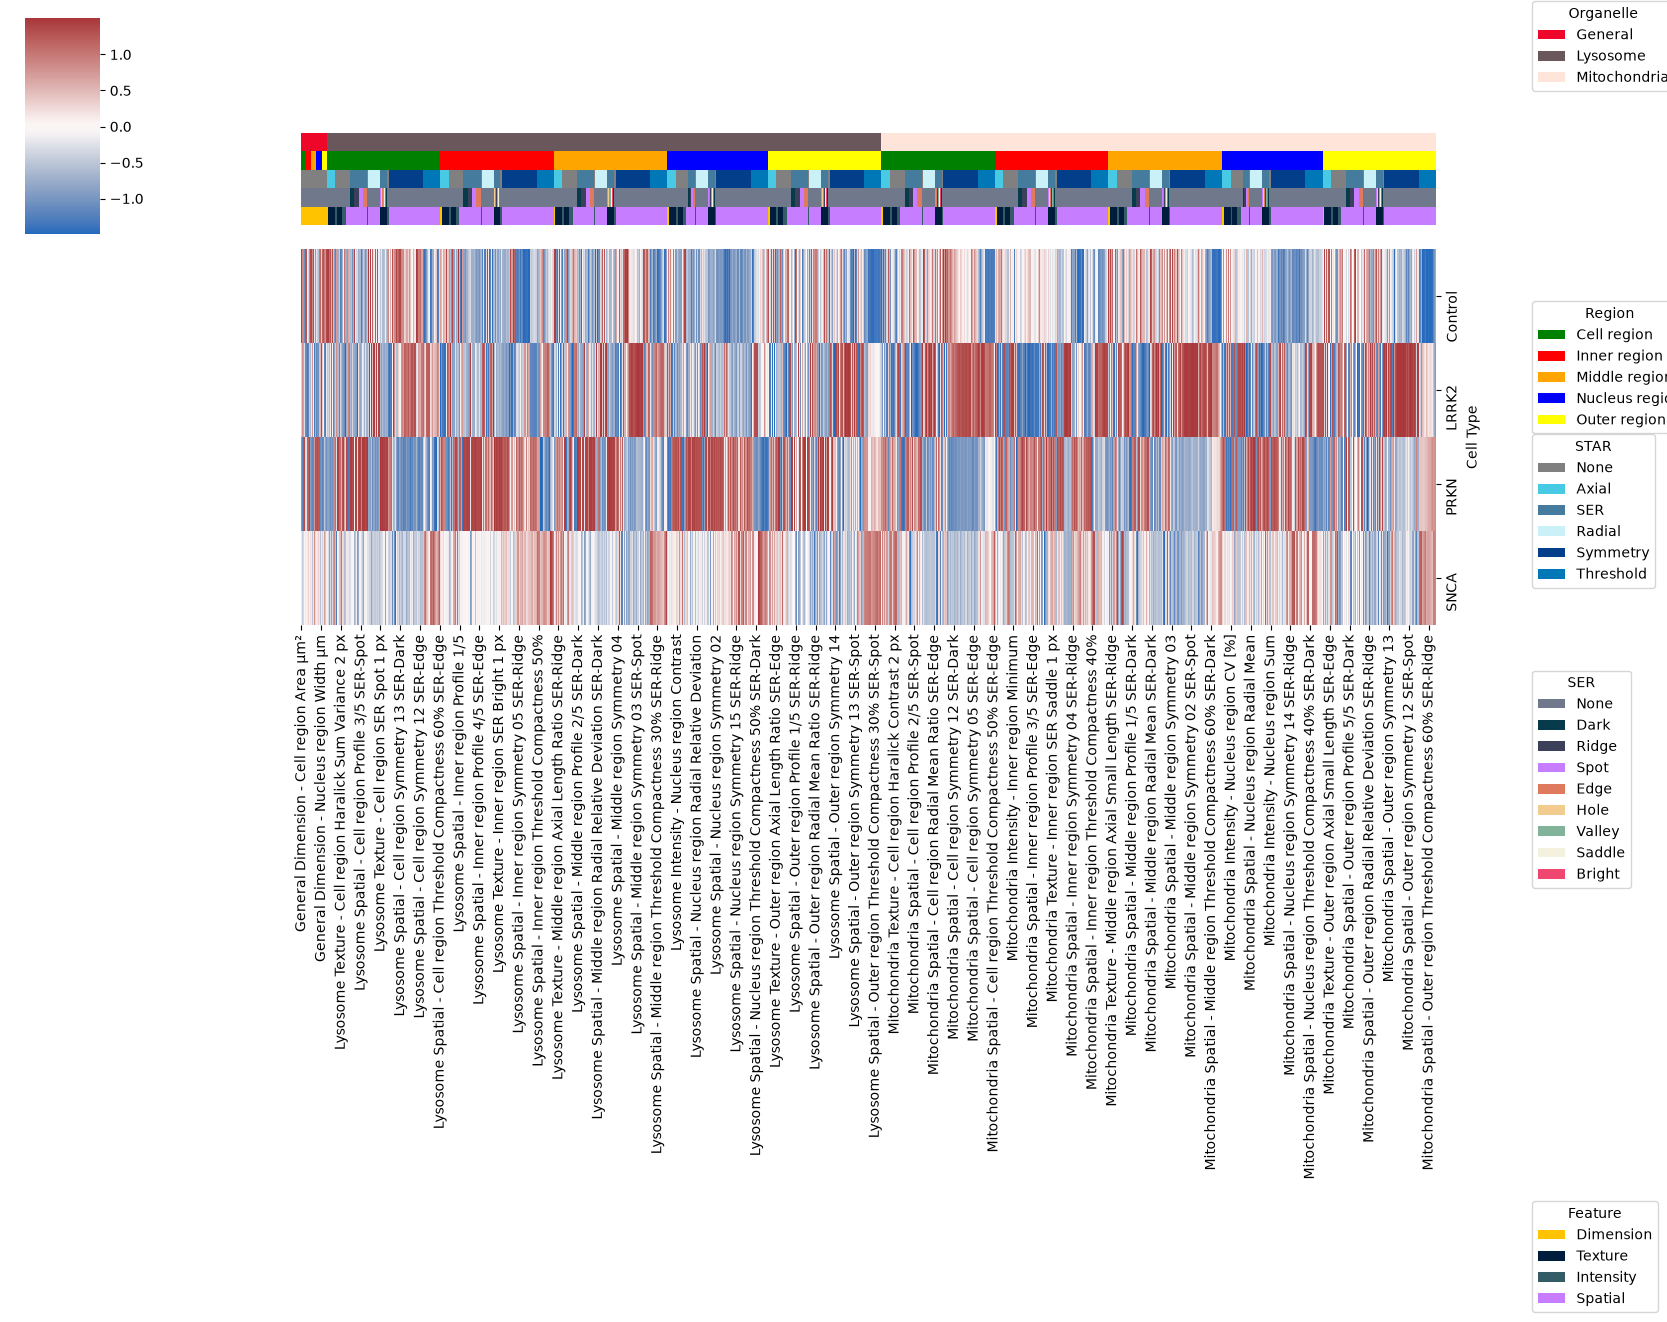

In [410]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = "#ef072a"
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = "#6A575C"

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#023e8a'
    elif star == 'Threshold':
        star_color = '#0077b6'
    elif star == 'Axial':
        star_color = '#48cae4'
    elif star == 'Radial':
        star_color = '#caf0f8'
    else:
        star_color = '#457b9d'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#ffc300'
    elif feature == 'Spatial':
        feature_color = '#c77dff'
    else:
        feature_color = '#001d3d'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# SER colours
ser_colours = [

]

lut_ser = {

}

for ser in ser_types:
    if ser == 'Saddle':
        ser_color = '#f4f1de'
    elif ser == 'Edge':
        ser_color = '#e07a5f'
    elif ser == 'Ridge':
        ser_color = '#3d405b'
    elif ser == 'Valley':
            ser_color = '#81b29a'
    elif ser == 'Hole':
            ser_color = '#f2cc8f'
    elif ser == 'Spot':
        ser_color = '#c77dff'
    elif ser == 'Dark':
        ser_color = '#073b4c'
    elif ser == 'Bright':
        ser_color = '#ef476f'
    else:
        ser_color = '#70798c'

    lut_ser[ser] = ser_color

    ser_colours.append(ser_color)    



# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]
handles_5 = [Patch(facecolor=lut_ser[name]) for name in lut_ser]

g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# SER
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')






In [335]:
heatmap_data[heatmap_data.columns[heatmap_data.std() == 0]]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
Cell Type,,,,,,,,,,
Control,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LRRK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PRKN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNCA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [336]:
heatmap_data = heatmap_data.astype('float')
print(np.isinf(heatmap_data).sum().sum())
print(heatmap_data.isna().sum().sum())
# print(heatmap_data)
zero_variance_cols = heatmap_data.columns[heatmap_data.std() == 0].tolist()
new_heatmap_data = heatmap_data
new_heatmap_data = new_heatmap_data.drop(columns=zero_variance_cols)

0
0


In [337]:
heatmap_data[zero_variance_cols]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
Cell Type,,,,,,,,,,
Control,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LRRK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PRKN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNCA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [338]:
print(zero_variance_cols)

['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']


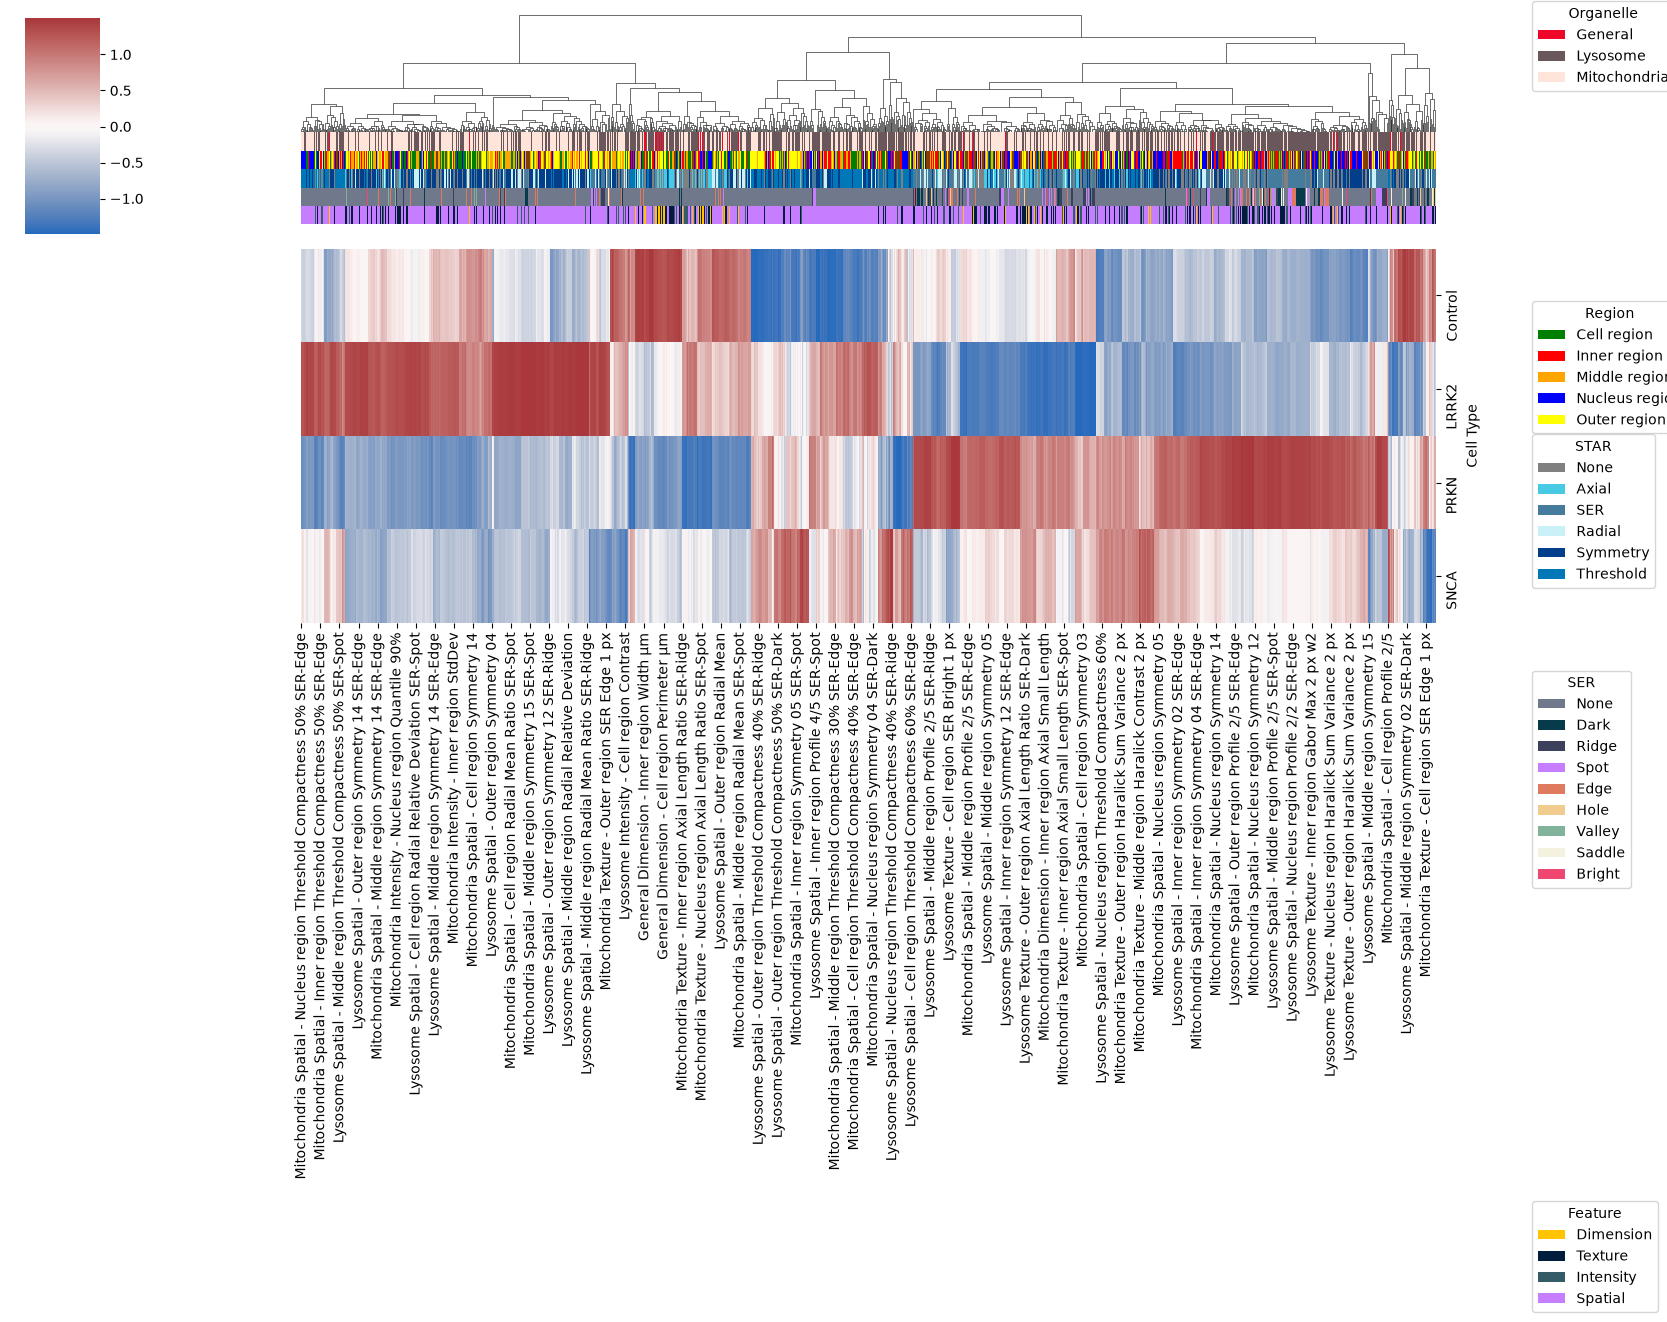

In [339]:
g = sns.clustermap(
    new_heatmap_data,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=True,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# The SER feature
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')




# ANOVA test

## Calculate the total variance for each column

In [340]:
counts = pd.read_csv('/home/rushik-sriramoju/cell_morphomics_dashboard_pipeline/cell_line_agg.csv')
counts

,Cellline ID,Cell Type,General Dimension - Nucleus region Area µm²,General Dimension - Nucleus region Roundness,General Dimension - Nucleus region Perimeter µm,General Dimension - Nucleus region Width µm,General Dimension - Nucleus region Length µm,General Dimension - Nucleus region Ratio Width to Length,General Dimension - Inner region Area µm²,General Dimension - Inner region Roundness,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,01-060 C9,PRKN,67.946315,0.914781,31.596994,7.122084,11.419451,0.639579,48.687567,0.333669,...,0.065262,0.047551,0.053530,0.070469,0.743751,0.266924,0.642336,0.249505,0.000416,0.003145
1,09-090 C18,PRKN,130.065552,0.838732,47.521225,8.713199,16.982723,0.542715,61.123065,0.270591,...,0.087697,0.052232,0.036871,0.097903,0.748054,0.361059,0.746866,0.322500,0.000715,0.005327
2,111450-107,Control,78.931746,0.920420,34.028156,7.744300,12.386339,0.641313,53.795965,0.331484,...,0.066566,0.054189,0.048099,0.075258,0.733000,0.241992,0.452307,0.244027,0.000524,0.003997
3,11302-101,Control,85.389591,0.924034,34.692041,7.999017,12.645884,0.647360,55.720516,0.319404,...,0.068447,0.051690,0.045649,0.076666,0.723425,0.253551,0.452969,0.254463,0.000530,0.004026
4,11555-104,SNCA,86.073801,0.915642,35.183439,7.951581,12.600431,0.654694,65.854881,0.336162,...,0.067242,0.054169,0.047672,0.075259,0.737148,0.268140,0.525461,0.255511,0.000503,0.003764
5,11556-110,SNCA,115.168152,0.833398,45.124623,8.345366,15.625873,0.563318,64.291799,0.288103,...,0.070784,0.045249,0.029053,0.076389,0.732905,0.444822,0.825245,0.401549,0.000662,0.004694
6,11557-103,SNCA,81.263283,0.915040,34.599771,7.748982,12.614239,0.629640,56.142437,0.330595,...,0.063117,0.048410,0.048634,0.070107,0.755164,0.261815,0.557979,0.248481,0.000412,0.003101
7,11576-101,LRRK2,98.174964,0.863077,38.954931,7.778117,13.942653,0.586682,71.723499,0.311442,...,0.051716,0.033858,0.027448,0.055842,0.720464,0.206805,0.515336,0.349847,0.000440,0.003197
8,14555-107,LRRK2,75.417705,0.918492,33.217232,7.545131,12.086598,0.638047,48.345514,0.322944,...,0.065156,0.049727,0.049404,0.070891,0.738615,0.279009,0.558219,0.245275,0.000419,0.003110
9,14557-107,LRRK2,70.124180,0.906361,32.374317,7.127540,11.814719,0.621882,44.394942,0.309938,...,0.066801,0.046739,0.047123,0.071226,0.707678,0.240527,0.519104,0.250502,0.000397,0.003039


In [341]:
no_cell_type = counts.drop(columns=['Cell Type', 'Cellline ID'])
# whole_variance = no_cell_type.agg(['var'])
# whole_variance

## Calculate the total variance per group

In [342]:
cell_type_cell_line = counts[['Cell Type', 'Cellline ID']]
counts = counts.drop(columns='Cellline ID')
# cell_type_var = counts.groupby(['Cell Type']).agg(['var'])
# cell_type_var

In [343]:
# Calculate the ratio of min to max variance per column
# def min_max_ratio(df):
#     if df.min() == 0:
#         return False
    
#     return df.max()/df.min() < 4

# min_max_var = pd.DataFrame(cell_type_var.agg(min_max_ratio), columns=['ANOVA safe'])
# min_max_var

In [344]:
# anova_safe_columns = min_max_var['ANOVA safe'].tolist()
cell_types = counts['Cell Type']
no_cell_types = counts.drop(columns=['Cell Type'])

# anova_safe_data = no_cell_types.loc[:, anova_safe_columns]
anova_safe_data = no_cell_types

In [345]:
anova_safe_data

,General Dimension - Nucleus region Area µm²,General Dimension - Nucleus region Roundness,General Dimension - Nucleus region Perimeter µm,General Dimension - Nucleus region Width µm,General Dimension - Nucleus region Length µm,General Dimension - Nucleus region Ratio Width to Length,General Dimension - Inner region Area µm²,General Dimension - Inner region Roundness,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Width µm,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,67.946315,0.914781,31.596994,7.122084,11.419451,0.639579,48.687567,0.333669,68.609308,3.152309,...,0.065262,0.047551,0.053530,0.070469,0.743751,0.266924,0.642336,0.249505,0.000416,0.003145
1,130.065552,0.838732,47.521225,8.713199,16.982723,0.542715,61.123065,0.270591,97.953138,2.898899,...,0.087697,0.052232,0.036871,0.097903,0.748054,0.361059,0.746866,0.322500,0.000715,0.005327
2,78.931746,0.920420,34.028156,7.744300,12.386339,0.641313,53.795965,0.331484,74.505125,3.121772,...,0.066566,0.054189,0.048099,0.075258,0.733000,0.241992,0.452307,0.244027,0.000524,0.003997
3,85.389591,0.924034,34.692041,7.999017,12.645884,0.647360,55.720516,0.319404,75.580352,2.990633,...,0.068447,0.051690,0.045649,0.076666,0.723425,0.253551,0.452969,0.254463,0.000530,0.004026
4,86.073801,0.915642,35.183439,7.951581,12.600431,0.654694,65.854881,0.336162,77.409949,3.368906,...,0.067242,0.054169,0.047672,0.075259,0.737148,0.268140,0.525461,0.255511,0.000503,0.003764
5,115.168152,0.833398,45.124623,8.345366,15.625873,0.563318,64.291799,0.288103,93.393290,3.053886,...,0.070784,0.045249,0.029053,0.076389,0.732905,0.444822,0.825245,0.401549,0.000662,0.004694
6,81.263283,0.915040,34.599771,7.748982,12.614239,0.629640,56.142437,0.330595,75.355107,3.289849,...,0.063117,0.048410,0.048634,0.070107,0.755164,0.261815,0.557979,0.248481,0.000412,0.003101
7,98.174964,0.863077,38.954931,7.778117,13.942653,0.586682,71.723499,0.311442,83.246488,3.162907,...,0.051716,0.033858,0.027448,0.055842,0.720464,0.206805,0.515336,0.349847,0.000440,0.003197
8,75.417705,0.918492,33.217232,7.545131,12.086598,0.638047,48.345514,0.322944,71.660942,3.041711,...,0.065156,0.049727,0.049404,0.070891,0.738615,0.279009,0.558219,0.245275,0.000419,0.003110
9,70.124180,0.906361,32.374317,7.127540,11.814719,0.621882,44.394942,0.309938,69.414127,2.789069,...,0.066801,0.046739,0.047123,0.071226,0.707678,0.240527,0.519104,0.250502,0.000397,0.003039


## Use the stats module to calculate the anova test for each column

In [346]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [347]:
np.random.seed(12)

# anova_safe_columns = anova_safe_data.columns
# print(anova_safe_columns)

# anova_safe_data['Cell Type'] = cell_types
# anova_safe_data

anova_safe_data = counts
anova_safe_columns = anova_safe_data.columns
print(anova_safe_columns)

Index(['Cell Type', 'General Dimension - Nucleus region Area µm²',
       'General Dimension - Nucleus region Roundness',
       'General Dimension - Nucleus region Perimeter µm',
       'General Dimension - Nucleus region Width µm',
       'General Dimension - Nucleus region Length µm',
       'General Dimension - Nucleus region Ratio Width to Length',
       'General Dimension - Inner region Area µm²',
       'General Dimension - Inner region Roundness',
       'General Dimension - Inner region Perimeter µm',
       ...
       'Mitochondria Texture - Outer region SER Valley 1 px',
       'Mitochondria Texture - Outer region SER Saddle 1 px',
       'Mitochondria Texture - Outer region SER Bright 1 px',
       'Mitochondria Texture - Outer region SER Dark 1 px',
       'Mitochondria Texture - Outer region Haralick Correlation 2 px',
       'Mitochondria Texture - Outer region Haralick Contrast 2 px',
       'Mitochondria Texture - Outer region Haralick Sum Variance 2 px',
       'Mito

In [348]:
signifcant_columns = []

# Overall significantly affected columns

In [349]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2'][col]
    prrkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]

    # Perform ANOVA
    if col != 'Cell Type':
        val = stats.f_oneway(control, lrrk2, prrkn, snca)
    
    
        print(col, ':')
        print(val)
        print("")

        if val.pvalue < 0.05:
            signifcant_columns.append(col)

    else:
        print("START!")

START!
General Dimension - Nucleus region Area µm² :
F_onewayResult(statistic=np.float64(0.22000959954717617), pvalue=np.float64(0.8801017654684424))

General Dimension - Nucleus region Roundness :
F_onewayResult(statistic=np.float64(0.3955508922068605), pvalue=np.float64(0.7594240696984288))

General Dimension - Nucleus region Perimeter µm :
F_onewayResult(statistic=np.float64(0.22443958193127864), pvalue=np.float64(0.8770545892340114))

General Dimension - Nucleus region Width µm :
F_onewayResult(statistic=np.float64(0.7195232834504031), pvalue=np.float64(0.565026494888568))

General Dimension - Nucleus region Length µm :
F_onewayResult(statistic=np.float64(0.1959419054099548), pvalue=np.float64(0.8965447220717175))

General Dimension - Nucleus region Ratio Width to Length :
F_onewayResult(statistic=np.float64(0.38528809474536835), pvalue=np.float64(0.7663192207362265))

General Dimension - Inner region Area µm² :
F_onewayResult(statistic=np.float64(0.2888268110332294), pvalue=np.flo

In [350]:
len(signifcant_columns)

31

In [406]:
print(signifcant_columns)

['Lysosome Intensity - Inner region Mean', 'Lysosome Intensity - Inner region Quantile 90%', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot', 'Lysosome Spatial - Cell region Threshold Compactness 30%', 'Lysosome Intensity - Outer region Sum', 'Lysosome Spatial - Outer region Symmetry 02 SER-Spot', 'Mitochondria Spatial - Nucleus region Threshold Compactness 40%', 'Mitochondria Spatial - Nucleus region Symmetry 03 SER-Dark', 'Mitochondria Spatial - Nucleus region Symmetry 04 SER-Dark', 'Mitochondria Spatial - Nucleus region Symmetry 05 SER-Dark', 'Mitochondria Spatial - Nucleus region Symmetry 13 SER-Dark', 'Mitochondria Spatial - Nucleus region Symmetry 15 SER-Dark', 'Mitochondria Spatial - Nucleus region Threshold Compactness 60% SER-Dark', 'Mitochondria Spatial - Inner region Symmetry 13 SER-Spot', 'Mitochondria Intensity - Middle region Minimum', 'Mitochondria Spatial - Middle region Threshold Compactness 30% SER-Dark', 

In [351]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [352]:
for col in signifcant_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

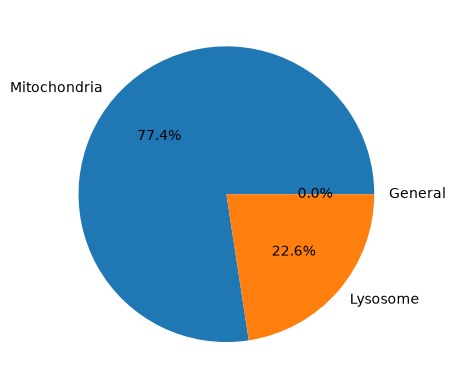

In [353]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# LRRK2 vs Control

In [385]:
lrrk2_sig_columns = []

In [386]:
for col in anova_safe_columns:
   

    # Perform ANOVA
    if col == 'Cell Type':
        print("BEGIN!")
    else:
        # Extract individual groups
        control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control']
        control = control[col]
        lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2']
        lrrk2 = lrrk2[col]
        
        val = stats.f_oneway(control, lrrk2)

        if val.pvalue < 0.05:
            lrrk2_sig_columns.append(col)
    
        print(col, ':')
        print(val)
        print("")

BEGIN!
General Dimension - Nucleus region Area µm² :
F_onewayResult(statistic=np.float64(0.5319709294209836), pvalue=np.float64(0.4984980152227143))

General Dimension - Nucleus region Roundness :
F_onewayResult(statistic=np.float64(0.8706868752239231), pvalue=np.float64(0.39359762685461464))

General Dimension - Nucleus region Perimeter µm :
F_onewayResult(statistic=np.float64(0.32540088224668184), pvalue=np.float64(0.5930575065481813))

General Dimension - Nucleus region Width µm :
F_onewayResult(statistic=np.float64(1.9072479706368015), pvalue=np.float64(0.22580458065092454))

General Dimension - Nucleus region Length µm :
F_onewayResult(statistic=np.float64(0.3626323142373313), pvalue=np.float64(0.573311869124856))

General Dimension - Nucleus region Ratio Width to Length :
F_onewayResult(statistic=np.float64(1.0327348937094238), pvalue=np.float64(0.35614197968872724))

General Dimension - Inner region Area µm² :
F_onewayResult(statistic=np.float64(0.47306342806384777), pvalue=np.f

In [387]:
print(lrrk2_sig_columns)
print(len(lrrk2_sig_columns))

['General Dimension - Outer region Area µm²', 'General Dimension - Outer region Width µm', 'Lysosome Intensity - Nucleus region Sum', 'Lysosome Spatial - Nucleus region Threshold Compactness 40%', 'Lysosome Spatial - Nucleus region Symmetry 03 SER-Dark', 'Lysosome Spatial - Nucleus region Symmetry 04 SER-Dark', 'Lysosome Spatial - Nucleus region Symmetry 05 SER-Dark', 'Lysosome Spatial - Nucleus region Symmetry 13 SER-Dark', 'Lysosome Spatial - Nucleus region Symmetry 15 SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Dark', 'Lysosome Spatial - Nucleus region Radial Relative Deviation SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Edge', 'Lysosome Spatial - Nucleus region Radial Mean Ratio SER-Edge', 'Lysosome Texture - Nucleus region SER Bright 1 px', 'Lysosome Spatial - Inner region Threshold Compactness 30% SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 04 SER-Spot

In [388]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [389]:
for col in lrrk2_sig_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

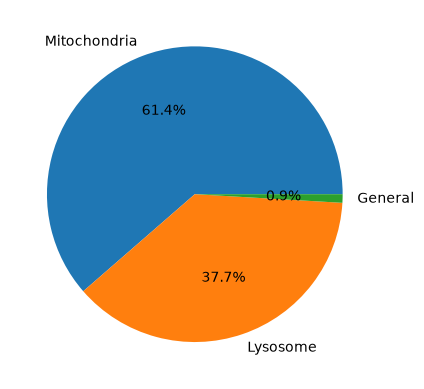

In [390]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# PRKN vs Control

In [397]:
prkn_sig_cols = []

In [398]:
for col in anova_safe_columns:
    # Extract individual groups
    # Perform ANOVA
    if col == 'Cell Type':
        print("BEGIN!")
    else:
        control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control']
        control = control[col]
        prkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN']
        prkn = prkn[col]
        
        # Perform ANOVA
        val = stats.f_oneway(control, prkn)

        if val.pvalue < 0.05:
                prkn_sig_cols.append(col)
        
        print(col, ':')
        print(val)
        print("")

BEGIN!
General Dimension - Nucleus region Area µm² :
F_onewayResult(statistic=np.float64(1.2903751795501926e-06), pvalue=np.float64(0.9991375741976993))

General Dimension - Nucleus region Roundness :
F_onewayResult(statistic=np.float64(1.2024733630344608), pvalue=np.float64(0.32281115273132144))

General Dimension - Nucleus region Perimeter µm :
F_onewayResult(statistic=np.float64(0.07214622664869788), pvalue=np.float64(0.7989673058306759))

General Dimension - Nucleus region Width µm :
F_onewayResult(statistic=np.float64(0.19610218491966286), pvalue=np.float64(0.6763875449898401))

General Dimension - Nucleus region Length µm :
F_onewayResult(statistic=np.float64(0.046848273509915904), pvalue=np.float64(0.8371949212635489))

General Dimension - Nucleus region Ratio Width to Length :
F_onewayResult(statistic=np.float64(1.1371982368908948), pvalue=np.float64(0.3350068587026589))

General Dimension - Inner region Area µm² :
F_onewayResult(statistic=np.float64(0.24945464393168806), pvalu

In [399]:
len(prkn_sig_cols)

37

In [400]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [401]:
for col in prkn_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

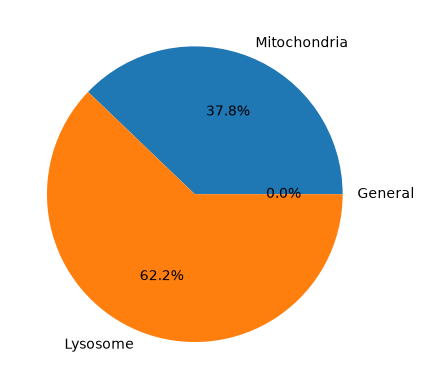

In [402]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# SNCA vs Control

In [403]:
snca_sig_cols = []

In [404]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]
    # Perform ANOVA
    if col == 'Cell Type':
        print("DONE!")
    else:
        # Perform ANOVA
        val = stats.f_oneway(control, snca)
        if val.pvalue < 0.05:
                snca_sig_cols.append(col)
        
        print(col, ':')
        print(val)
        print("")

DONE!
General Dimension - Nucleus region Area µm² :
F_onewayResult(statistic=np.float64(0.001707042438423627), pvalue=np.float64(0.9686427639156172))

General Dimension - Nucleus region Roundness :
F_onewayResult(statistic=np.float64(0.9150183399063383), pvalue=np.float64(0.38271696371077496))

General Dimension - Nucleus region Perimeter µm :
F_onewayResult(statistic=np.float64(0.11066138052225383), pvalue=np.float64(0.7528866060426403))

General Dimension - Nucleus region Width µm :
F_onewayResult(statistic=np.float64(0.11044525212976762), pvalue=np.float64(0.7531176880293119))

General Dimension - Nucleus region Length µm :
F_onewayResult(statistic=np.float64(0.022706580110875195), pvalue=np.float64(0.8861131198201576))

General Dimension - Nucleus region Ratio Width to Length :
F_onewayResult(statistic=np.float64(0.45836497829566547), pvalue=np.float64(0.5284403277713283))

General Dimension - Inner region Area µm² :
F_onewayResult(statistic=np.float64(0.10219997981511673), pvalue=

In [405]:
print(snca_sig_cols)
print(len(snca_sig_cols))

['Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 40% SER-Dark', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot', 'Lysosome Spatial - Outer region Symmetry 03', 'Mitochondria Spatial - Nucleus region Symmetry 05 SER-Dark', 'Mitochondria Spatial - Nucleus region Threshold Compactness 30% SER-Edge', 'Mitochondria Spatial - Nucleus region Threshold Compactness 40% SER-Edge', 'Mitochondria Intensity - Middle region CV [%]', 'Mitochondria Spatial - Middle region Profile 3/5 SER-Edge', 'Mitochondria Texture - Middle region Haralick Sum Variance 2 px', 'Mitochondria Intensity - Cell region CV [%]', 'Mitochondria Spatial - Cell region Profile 3/5 SER-Edge', 'Mitochondria Texture - Cell region Haralick Sum Variance 2 px', 'Mitochondria Intensity - Outer region CV [%]']
15


In [407]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [408]:
for col in snca_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

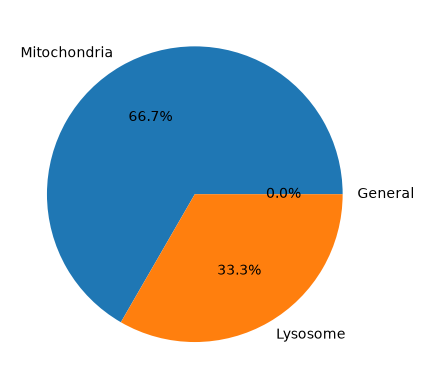

In [409]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')